# 04 - E4: PhoBERT với sqrt-inverse class weight

Notebook này fine-tune `vinai/phobert-base-v2` với sqrt-inverse class
weight. Chiến lược này vẫn ưu tiên các lớp hiếm nhưng giảm độ chênh
trọng số so với inverse-frequency weighting của E3

Trọng số chỉ được tính từ training split. Checkpoint được chọn bằng
Punctuation Macro-F1 trên validation; official test không tham gia
model selection. Artifact được lưu tại `outputs/experiments/E4/` và
`outputs/checkpoints/E4/`


In [ ]:
import os, sys, json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "src").exists(), f"Cannot locate the repo root from {Path.cwd()}"
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd

from src.data.constants import (
    LABELS, LABEL2ID, PUNCTUATION_LABELS, MONITOR_METRIC,
    PROCESSED_FILES, OUTPUT_DATA_DIR, CHECKPOINT_DIR, EXPERIMENT_DIR, SEED,
)
from src.data.dataset import load_examples
from src.evaluation.evaluator import predict_word_labels, sample_predictions
from src.evaluation.metrics import format_metrics_table
from src.models.factory import load_model_from_checkpoint
from src.training.seed import set_seed
from src.utils.environment import collect_environment, format_environment
from src.utils.io import read_json, read_yaml
from src.utils.logging_utils import configure_stdout_utf8

configure_stdout_utf8()

EXPERIMENT_ID = "E4"
CONFIG_PATH   = PROJECT_ROOT / "configs" / "e4_phobert_sqrt_inverse.yaml"

print(f"Project root : {PROJECT_ROOT}")
print(f"Experiment   : {EXPERIMENT_ID}")
print(f"Config       : {CONFIG_PATH.relative_to(PROJECT_ROOT)}\n")
print(format_environment())

Project root : <USER_HOME>/Documents\GitHub\NLPgrSix7
Experiment   : E4
Config       : configs\e4_phobert_sqrt_inverse.yaml

Python version      : 3.12.4
Platform            : Windows-11-10.0.26100-SP0
PyTorch version     : 2.13.0+cu126
CUDA available      : True
CUDA runtime        : 12.6
GPU name            : NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory (GB)     : 8.0
Transformers version: 5.14.1
NumPy version       : 2.5.1


## 1. Chuẩn bị dữ liệu

Dữ liệu đến từ [JointCapPunc](https://github.com/ductho9799/JointCapPunc),
được cố định tại commit `ee258cae0e95e64245428d59ebbb030280fcebec`. Notebook
đọc `train.jsonl` để huấn luyện và `validation.jsonl` để đánh giá sau mỗi
epoch. Split test không được nạp ở giai đoạn này

Pipeline trước đó đã chuẩn hóa Unicode NFC, ánh xạ `QMARK` thành `QUESTION`,
chia chuỗi thành các mẫu không quá 150 từ và loại bản ghi trùng trong từng
split. Hash nội dung của dữ liệu được lưu cùng artifact và checkpoint để có
thể đối chiếu nguồn dữ liệu giữa các thí nghiệm


In [ ]:
config = read_yaml(CONFIG_PATH)

data_cfg = config["data"]
assert "test" not in json.dumps(data_cfg), "test split must not appear in the training config"
print("Files this notebook is allowed to read:")
print("  train      :", data_cfg["train_file"])
print("  validation :", data_cfg["validation_file"])
print("  test       : NOT LOADED  <-- reserved for Phase 2\n")

data_hashes = read_json(OUTPUT_DATA_DIR / "data_hashes.json")
for split in ("train", "validation"):
    h = data_hashes[split]
    print(f"  {split:<11} {h['num_examples']:>7,} examples  "
          f"{h['num_tokens']:>11,} tokens  content_sha256={h['content_sha256'][:16]}…")

set_seed(int(config["training"]["seed"]))

t0 = time.time()
train_examples      = load_examples(PROCESSED_FILES["train"])
validation_examples = load_examples(PROCESSED_FILES["validation"])
print(f"\nLoaded {len(train_examples):,} train / {len(validation_examples):,} validation "
      f"examples in {time.time() - t0:.1f}s")

Files this notebook is allowed to read:
  train      : data/processed/train.jsonl
  validation : data/processed/validation.jsonl
  test       : NOT LOADED  <-- reserved for Phase 2

  train        38,066 examples    4,940,478 tokens  content_sha256=138983bc2761546f…
  validation   15,227 examples    1,977,406 tokens  content_sha256=874133954b31fbfd…
2026-08-09 23:53:49 | INFO    | src.training.seed | Seed set to 42 (deterministic=False)
2026-08-09 23:53:52 | INFO    | src.data.dataset | Loaded 38066 examples from train.jsonl
2026-08-09 23:53:53 | INFO    | src.data.dataset | Loaded 15227 examples from validation.jsonl

Loaded 38,066 train / 15,227 validation examples in 3.4s


In [ ]:
stats = read_json(OUTPUT_DATA_DIR / "data_statistics.json")

rows = []
for split in ("train", "validation"):
    s = stats["splits"][split]
    row = {"split": split, "examples": s["num_examples"], "tokens": s["num_tokens"],
           "mean_len": round(s["mean_length"], 1), "max_len": s["max_length"]}
    for lab in LABELS:
        row[f"%{lab}"] = round(100 * s["label_ratios"][lab], 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("split"))

ex = train_examples[0]
print("\nVí dụ một dòng dữ liệu (10 từ đầu):")
for tok, lab in list(zip(ex.tokens, ex.labels))[:10]:
    print(f"   {tok:<14} -> {lab}")
print(f"   … tổng cộng {len(ex.tokens)} từ, id={ex.id}, source_id={ex.source_id}")

,examples,tokens,mean_len,max_len,%O,%COMMA,%PERIOD,%QUESTION
split,,,,,,,,
train,38066,4940478,129.8,150,91.101,4.616,3.728,0.556
validation,15227,1977406,129.9,150,91.058,4.643,3.743,0.556



Ví dụ một dòng dữ liệu (10 từ đầu):
   hơn            -> O
   2              -> O
   tháng          -> O
   qua            -> O
   amidan         -> O
   khẩu           -> O
   cái            -> O
   của            -> O
   em             -> O
   có             -> O
   … tổng cộng 93 từ, id=train_000001, source_id=train_seg_000001


## 2. Mô hình PhoBERT

Mô hình sử dụng `vinai/phobert-base-v2` với đầu ra token classification gồm
bốn lớp. Toàn bộ backbone được fine-tune; lớp tuyến tính cuối ánh xạ biểu diễn
ẩn của mỗi subword thành logits cho `O`, `COMMA`, `PERIOD` và `QUESTION`

Revision `fb76b7e1f77fa19bc4870e2ad956876f7c81c53f` được cố định để E2, E3 và E4
khởi tạo từ cùng một bộ trọng số. Loss được tính trong trainer thay vì bên
trong wrapper của Hugging Face, nhờ đó ba thí nghiệm có thể dùng các chiến
lược class weight khác nhau mà không đổi kiến trúc model


## 3. Căn chỉnh từ và subword

Nhãn dấu câu được định nghĩa ở mức từ, trong khi PhoBERT xử lý BPE subword.
Mỗi nhãn vì vậy được đặt tại subword cuối cùng của từ tương ứng. Các subword
còn lại, token đặc biệt và padding nhận `IGNORE_INDEX = -100` để không tham
gia tính loss

```text
từ:        hoàn          thành       chưa
subword:   ho@@  àn      thành       ch@@  ưa
nhãn:      -100  O       PERIOD      -100  QUESTION
```

Với chuỗi vượt quá 192 subword, `PhoBERTEncoder` tạo nhiều cửa sổ tại ranh
giới từ thay vì cắt bỏ phần cuối. Các kiểm thử trong `tests/test_alignment.py`
xác nhận mỗi từ được giám sát đúng một lần và thứ tự từ được giữ nguyên


In [ ]:
from src.data.constants import IGNORE_INDEX, PHOBERT_MAX_LENGTH
from src.data.dataset import PhoBERTEncoder
from src.models.phobert import load_phobert_tokenizer

tokenizer = load_phobert_tokenizer(config["model"]["name"], config["model"]["revision"])
print(f"Tokenizer     : {type(tokenizer).__name__}")
print(f"Model         : {config['model']['name']}")
print(f"Revision      : {config['model']['revision']}")
print(f"Vocab size    : {tokenizer.vocab_size:,}")
print(f"Window length : {config['model']['max_length']} subwords\n")

encoder = PhoBERTEncoder(tokenizer, max_length=int(config["model"]["max_length"]))

from src.data.schema import Example
demo = Example(
    id="demo", source_split="train", source_id="demo_seg", chunk_index=0,
    tokens="bạn đã hoàn thành bài tập chưa ngày mai chúng ta nộp bài".split(),
    labels=["O"] * 6 + ["QUESTION"] + ["O"] * 5 + ["PERIOD"],
)
(window,) = encoder.encode_example(demo)
id2label = {v: k for k, v in LABEL2ID.items()}

print(f"{'pos':>4}  {'subword':<14}{'label':<10}{'thuộc từ':<10}")
print("-" * 44)
for pos, (sid, lab, widx) in enumerate(zip(window.input_ids, window.labels, window.word_index)):
    piece = tokenizer.convert_ids_to_tokens([sid])[0]
    label_txt = "IGNORE(-100)" if lab == IGNORE_INDEX else f"{id2label[lab]}"
    word_txt  = "-" if widx < 0 else f"{widx} ({demo.tokens[widx]})"
    print(f"{pos:>4}  {piece:<14}{label_txt:<14}{word_txt}")

supervised = [w for w in window.word_index if w >= 0]
print(f"\nSố từ = {len(demo.tokens)} | số vị trí được giám sát = {len(supervised)} "
      f"| khớp: {supervised == list(range(len(demo.tokens)))}")

2026-08-09 23:53:55 | INFO    | httpx | HTTP Request: HEAD https://huggingface.co/vinai/phobert-base-v2/resolve/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f/tokenizer_config.json "HTTP/1.1 404 Not Found"


2026-08-09 23:53:55 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-08-09 23:53:55 | INFO    | httpx | HTTP Request: HEAD https://huggingface.co/vinai/phobert-base-v2/resolve/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f/tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-08-09 23:53:55 | INFO    | httpx | HTTP Request: GET https://huggingface.co/api/models/vinai/phobert-base-v2/tree/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-08-09 23:53:56 | INFO    | httpx | HTTP Request: GET https://huggingface.co/api/models/vinai/phobert-base-v2/tree/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f?recursive=true&expand=false "HTTP/1.1 200 OK"
Tokenizer     : PhobertTokenizer
Model         : vinai/phobert-base-v2
Revision      : fb76b7e1f77fa19bc4870e2ad956876f7c81c53f
Vocab size    : 64,000
Win

## 4. Sqrt-inverse class weight

E4 dùng `CrossEntropyLoss(weight=sqrt_inverse_weights,
ignore_index=-100)` với:

$$
w_c = \sqrt{\frac{N_{train}}{C \times n_c}}
$$

Phép căn bậc hai giữ nguyên thứ tự ưu tiên giữa các lớp nhưng nén biên
độ trọng số. Trong artifact hiện tại, tỷ lệ giữa trọng số lớn nhất và
nhỏ nhất giảm từ khoảng 164 lần ở E3 xuống khoảng 12.8 lần ở E4

E4 kiểm tra liệu mức weighting nhẹ hơn có cân bằng precision và recall
tốt hơn inverse weighting hay không. Kết luận được rút ra từ validation
metric sau khi cả E2, E3 và E4 hoàn tất


In [ ]:
from src.training.losses import get_class_weight_vector, load_class_weights

class_weights_blob = load_class_weights()
weight_mode        = config["loss"]["weight_mode"]
weight_vector      = get_class_weight_vector(weight_mode, class_weights=class_weights_blob)

print(f"weight_mode  : {weight_mode}")
print(f"nguồn trọng số: {class_weights_blob['source_split']} split "
      f"({class_weights_blob['total_train_tokens']:,} tokens)\n")

table = []
for i, lab in enumerate(LABELS):
    table.append({
        "label": lab,
        "train_count": class_weights_blob["counts"][lab],
        "train_share_%": round(100 * class_weights_blob["frequencies"][lab], 3),
        "inverse": round(class_weights_blob["inverse"][lab], 4),
        "sqrt_inverse": round(class_weights_blob["sqrt_inverse"][lab], 4),
        "USED HERE": "1.0 (none)" if weight_vector is None else round(weight_vector[i], 4),
    })
display(pd.DataFrame(table).set_index("label"))

weight_mode  : sqrt_inverse
nguồn trọng số: train split (4,940,478 tokens)



,train_count,train_share_%,inverse,sqrt_inverse,USED HERE
label,,,,,
O,4500812,91.101,0.2744,0.5239,0.5239
COMMA,228032,4.616,5.4164,2.3273,2.3273
PERIOD,184186,3.728,6.7058,2.5896,2.5896
QUESTION,27448,0.556,44.9985,6.7081,6.7081


## 5. Cấu hình huấn luyện

Các tham số được đọc từ `configs/e4_phobert_sqrt_inverse.yaml`:

| Tham số | Giá trị |
|---|---|
| Epoch | 5 |
| Train batch size | 4 |
| Gradient accumulation | 4 |
| Effective batch size | xấp xỉ 16 |
| Evaluation batch size | 8 |
| Optimizer | AdamW |
| Learning rate | `3e-5` |
| Weight decay | `1e-2` |
| Warmup ratio | 0.10 |
| Gradient clipping | 1.0 |
| Maximum length | 192 subword |
| Loss weight mode | `sqrt_inverse` |
| Seed | 42 |

Scheduler thực hiện linear warmup rồi giảm learning rate theo từng optimizer
step


In [ ]:
def flatten(prefix, obj, out):
    for k, v in obj.items():
        key = f"{prefix}.{k}" if prefix else k
        if isinstance(v, dict):
            flatten(key, v, out)
        else:
            out.append({"parameter": key, "value": v})
    return out

display(pd.DataFrame(flatten("", config, [])).set_index("parameter"))

,value
parameter,
experiment.id,E4
experiment.name,PhoBERT — sqrt-inverse class weights
experiment.description,"Same setup as E2, but CrossEntropyLoss is weig..."
model.type,phobert
model.name,vinai/phobert-base-v2
model.revision,fb76b7e1f77fa19bc4870e2ad956876f7c81c53f
model.num_labels,4
model.max_length,192
model.dropout,None


## 6. Huấn luyện

PhoBERT được fine-tune với mixed precision khi có CUDA. Mỗi micro-batch gồm 4
cửa sổ và gradient được tích lũy qua 4 bước, tạo effective batch size xấp xỉ
16 mà không cần giữ toàn bộ batch trong VRAM

Sau mỗi chu kỳ tích lũy, trainer unscale gradient nếu dùng fp16, clip gradient
norm ở 1.0 rồi cập nhật optimizer và scheduler. Phần gradient còn lại ở cuối
epoch vẫn được áp dụng. Validation được chạy sau từng epoch và checkpoint chỉ
được ghi khi Punctuation Macro-F1 được cải thiện


In [ ]:
from src.training.trainer_phobert import build_phobert_trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")

trainer, tokenizer = build_phobert_trainer(
    config,
    train_examples,
    validation_examples,
    tokenizer=tokenizer,
    data_hashes=data_hashes,
    device=device,
)

n_params = sum(p_.numel() for p_ in trainer.model.parameters())
accum    = trainer.gradient_accumulation_steps
print(f"\nModel parameters      : {n_params:,} ({n_params / 1e6:.1f}M)")
print(f"Train windows         : {len(trainer.train_loader.dataset):,}")
print(f"Validation windows    : {len(trainer.validation_loader.dataset):,}")
print(f"Micro-batches / epoch : {len(trainer.train_loader):,}")
print(f"Optimizer steps/epoch : {len(trainer.train_loader) // accum:,} "
      f"(accumulation = {accum}, effective batch = {trainer.train_loader.batch_size * accum})")
print(f"Mixed precision (fp16): {trainer.use_amp}")

Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB)
2026-08-09 23:53:56 | INFO    | src.training.seed | Seed set to 42 (deterministic=False)
2026-08-09 23:53:59 | INFO    | src.data.dataset | Encoded 20000/38066 examples
2026-08-09 23:54:01 | INFO    | src.data.dataset | PhoBERT dataset ready: {'num_examples': 38066, 'num_windows': 38111, 'num_words': 4940478, 'num_subwords': 5207406, 'windows_per_example': 1.0012, 'subwords_per_word': 1.054, 'examples_split_into_multiple_windows': 45, 'max_window_length': 192}
2026-08-09 23:54:03 | INFO    | src.data.dataset | PhoBERT dataset ready: {'num_examples': 15227, 'num_windows': 15243, 'num_words': 1977406, 'num_subwords': 2083427, 'windows_per_example': 1.0011, 'subwords_per_word': 1.0536, 'examples_split_into_multiple_windows': 16, 'max_window_length': 192}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-08-09 23:54:03 | INFO    | src.models.phobert | Loaded vinai/phobert-base-v2 @ fb76b7e1f77f (134.4M parameters, num_labels=4)
2026-08-09 23:54:04 | INFO    | src.training.losses | Loss: CrossEntropyLoss(weight_mode=sqrt_inverse, weights=[0.5239, 2.3273, 2.5896, 6.7081], ignore_index=-100)
2026-08-09 23:54:04 | INFO    | src.training.optimizer | AdamW(lr=3e-05, weight_decay=0.01, betas=(0.9, 0.999), eps=1e-08) — 134,289,408 decayed / 121,348 not decayed params
2026-08-09 23:54:04 | INFO    | src.training.scheduler | Scheduler: linear warmup+decay (1191 warmup / 11910 total optimizer steps, ratio=0.10)

Model parameters      : 134,410,756 (134.4M)
Train windows         : 38,111
Validation windows    : 15,243
Micro-batches / epoch : 9,528
Optimizer steps/epoch : 2,382 (accumulation = 4, effective batch = 16)
Mixed precision (fp16): True


In [ ]:
result = trainer.fit()

print("\n" + "=" * 78)
print(f"TRAINING FINISHED — best epoch {result.best_epoch}, "
      f"validation {MONITOR_METRIC} = {result.best_score:.6f}")
print(f"Total time: {result.total_seconds / 60:.1f} min")
print("=" * 78)

2026-08-09 23:54:04 | INFO    | src.training.trainer_base | === E4: training for 5 epoch(s) on cuda (AMP=True) ===


E4 epoch 1 train:   0%|          | 0/9528 [00:00<?, ?it/s]

2026-08-09 23:57:42 | INFO    | src.training.trainer_phobert | epoch 1 step 500/9528 — loss 1.1690 (lr=3.15e-06)
2026-08-10 00:01:17 | INFO    | src.training.trainer_phobert | epoch 1 step 1000/9528 — loss 0.8943 (lr=6.30e-06)
2026-08-10 00:04:54 | INFO    | src.training.trainer_phobert | epoch 1 step 1500/9528 — loss 0.7328 (lr=9.45e-06)
2026-08-10 00:08:29 | INFO    | src.training.trainer_phobert | epoch 1 step 2000/9528 — loss 0.6352 (lr=1.26e-05)
2026-08-10 00:12:05 | INFO    | src.training.trainer_phobert | epoch 1 step 2500/9528 — loss 0.5706 (lr=1.57e-05)
2026-08-10 00:15:39 | INFO    | src.training.trainer_phobert | epoch 1 step 3000/9528 — loss 0.5235 (lr=1.89e-05)
2026-08-10 00:19:16 | INFO    | src.training.trainer_phobert | epoch 1 step 3500/9528 — loss 0.4883 (lr=2.20e-05)
2026-08-10 00:22:52 | INFO    | src.training.trainer_phobert | epoch 1 step 4000/9528 — loss 0.4606 (lr=2.52e-05)
2026-08-10 00:26:27 | INFO    | src.training.trainer_phobert | epoch 1 step 4500/9528 — l

E4 epoch 1 validation:   0%|          | 0/1906 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

E4 epoch 5 train:   0%|          | 0/9528 [00:00<?, ?it/s]

2026-08-10 04:32:34 | INFO    | src.training.trainer_phobert | epoch 5 step 500/9528 — loss 0.1457 (lr=6.32e-06)
2026-08-10 04:36:07 | INFO    | src.training.trainer_phobert | epoch 5 step 1000/9528 — loss 0.1445 (lr=5.97e-06)
2026-08-10 04:39:39 | INFO    | src.training.trainer_phobert | epoch 5 step 1500/9528 — loss 0.1457 (lr=5.62e-06)
2026-08-10 04:43:10 | INFO    | src.training.trainer_phobert | epoch 5 step 2000/9528 — loss 0.1454 (lr=5.27e-06)
2026-08-10 04:46:47 | INFO    | src.training.trainer_phobert | epoch 5 step 2500/9528 — loss 0.1450 (lr=4.92e-06)
2026-08-10 04:50:22 | INFO    | src.training.trainer_phobert | epoch 5 step 3000/9528 — loss 0.1452 (lr=4.57e-06)
2026-08-10 04:54:02 | INFO    | src.training.trainer_phobert | epoch 5 step 3500/9528 — loss 0.1456 (lr=4.22e-06)
2026-08-10 04:57:37 | INFO    | src.training.trainer_phobert | epoch 5 step 4000/9528 — loss 0.1458 (lr=3.87e-06)
2026-08-10 05:01:11 | INFO    | src.training.trainer_phobert | epoch 5 step 4500/9528 — l

E4 epoch 5 validation:   0%|          | 0/1906 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-08-10 05:37:49 | INFO    | src.training.checkpointing | Epoch 5: new best punctuation_macro_f1=0.745676 (was 0.740721) — checkpoint written to outputs\checkpoints\E4

[E4] epoch 5/5 (68.8 min) — train_loss=0.1455 val_loss=0.2047 val_PUNCT_F1=0.7457  <-- new best
label       precision    recall        f1     support
-----------------------------------------------------
O              0.9940    0.9694    0.9815   1,800,593
COMMA          0.6228    0.7998    0.7003      91,818
PERIOD         0.7320    0.8604    0.7911      74,008
QUESTION       0.6198    0.9357    0.7457      10,987
-----------------------------------------------------
accuracy       0.9572
macro F1       0.8046   (all 4 classes)
PUNCT-F1       0.7457   <-- model selection metric (COMMA/PERIOD/QUESTION)

TRAINING FINISHED — best epoch 5, validation punctuation_macro_f1 = 0.745676
Total time: 343.7 min


## 7. Đánh giá trên validation

Metric dùng để chọn checkpoint là Punctuation Macro-F1:

$$
\text{Punctuation Macro-F1}
= \frac{F1_{COMMA} + F1_{PERIOD} + F1_{QUESTION}}{3}
$$

Lớp `O` không được đưa vào metric chính vì chiếm hơn 91% số token. Cách tính
macro cũng giúp `QUESTION`, lớp hiếm nhất, có vai trò ngang với `COMMA` và
`PERIOD`. Accuracy, macro-F1 bốn lớp, precision và recall vẫn được lưu để phân
tích nhưng không quyết định checkpoint


In [ ]:
best_metrics = trainer.checkpoints.best_metrics
artifacts    = trainer.artifacts

artifacts.write_best_validation(best_metrics, best_epoch=result.best_epoch)
artifacts.write_per_class(best_metrics)
artifacts.write_confusion_matrix(best_metrics)
artifacts.write_history()

print(f"Best epoch                 : {result.best_epoch}")
print(f"Validation PUNCT Macro-F1  : {best_metrics['punctuation_macro_f1']:.6f}")
print(f"Validation accuracy        : {best_metrics['accuracy']:.6f}")
print(f"Validation macro-F1 (4 cls): {best_metrics['macro_f1']:.6f}")
print(f"Supervised tokens scored   : {best_metrics['num_evaluated_tokens']:,}")

Best epoch                 : 5
Validation PUNCT Macro-F1  : 0.745676
Validation accuracy        : 0.957236
Validation macro-F1 (4 cls): 0.804645
Supervised tokens scored   : 1,977,406


## 8. Theo dõi quá trình huấn luyện

Biểu đồ bên trái đối chiếu train loss và validation loss theo epoch. Biểu đồ
bên phải theo dõi validation Punctuation Macro-F1 cùng macro-F1 trên bốn lớp;
epoch có metric chính cao nhất được đánh dấu là checkpoint tốt nhất


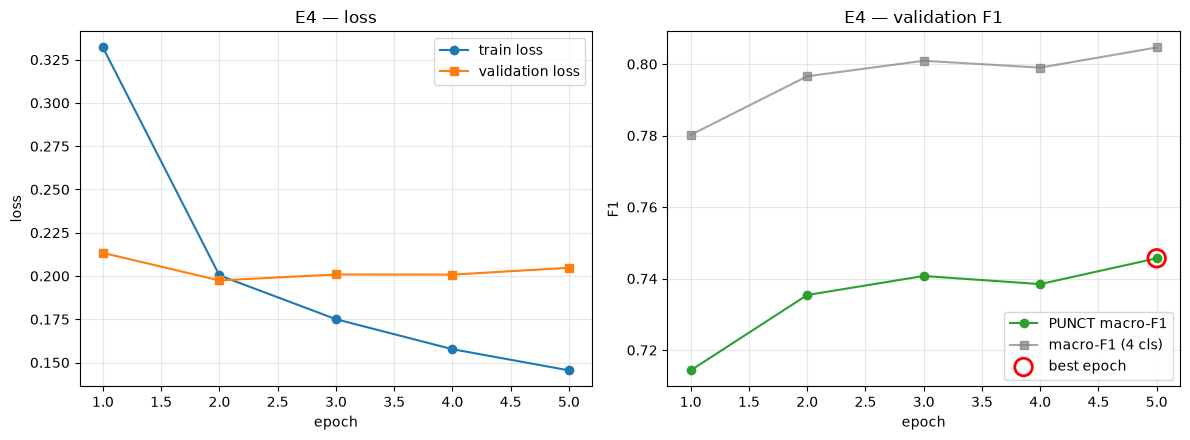

Saved: outputs\experiments\E4\training_curves.png


,epoch,train_loss,val_loss,val_accuracy,val_punctuation_macro_f1,val_f1_COMMA,val_f1_PERIOD,val_f1_QUESTION,learning_rate,epoch_seconds,is_best
0,1,0.33206,0.21334,0.94946,0.71433,0.66038,0.76345,0.71915,0.00000,4135.68,1
1,2,0.20036,0.19746,0.95446,0.73540,0.68486,0.78588,0.73546,0.00003,4126.07,1
2,3,0.17504,0.20086,0.95710,0.74072,0.69986,0.78830,0.73400,0.00002,4114.86,1
3,4,0.15770,0.20080,0.95549,0.73845,0.69469,0.78041,0.74026,0.00001,4119.29,0
4,5,0.14547,0.20473,0.95724,0.74568,0.70031,0.79106,0.74566,0.00001,4128.64,1


In [ ]:
%matplotlib inline
curve_path = artifacts.plot_training_curves(show=True)
print("Saved:", curve_path)

history_df = pd.read_csv(artifacts.path("training_history.csv"))
display(history_df[[
    "epoch", "train_loss", "val_loss", "val_accuracy",
    "val_punctuation_macro_f1", "val_f1_COMMA", "val_f1_PERIOD", "val_f1_QUESTION",
    "learning_rate", "epoch_seconds", "is_best",
]].round(5))

## 9. Checkpoint tốt nhất

Mỗi thí nghiệm chỉ giữ checkpoint có validation Punctuation Macro-F1 cao nhất,
không mặc định dùng trạng thái của epoch cuối. `checkpoint_metadata.json` lưu
experiment id, cấu hình, label mapping, best epoch, validation score, hash dữ
liệu, seed và thông tin môi trường cần thiết để kiểm tra lại kết quả


In [ ]:
ckpt_dir = Path(trainer.checkpoints.checkpoint_dir)
meta     = read_json(ckpt_dir / "checkpoint_metadata.json")

print(f"Checkpoint directory: {ckpt_dir.relative_to(PROJECT_ROOT)}\n")
for f in sorted(ckpt_dir.iterdir()):
    print(f"  {f.name:<32}{f.stat().st_size / 1024:>12,.0f} KB")

print("\nMetadata:")
for key in ("experiment_id", "model_type", "model_name", "model_revision",
            "monitor_metric", "best_epoch", "best_score", "seed",
            "python_version", "torch_version", "transformers_version",
            "cuda_version", "gpu_name"):
    print(f"  {key:<22}: {meta.get(key)}")
print(f"  {'label2id':<22}: {meta.get('label2id')}")
print(f"  {'train content_sha256':<22}: {meta['data_hashes']['train']['content_sha256'][:32]}…")

Checkpoint directory: outputs\checkpoints\E4

  .gitkeep                                   0 KB
  added_tokens.json                          0 KB
  bpe.codes                              1,109 KB
  checkpoint_metadata.json                   6 KB
  config.json                                1 KB
  model.safetensors                    525,065 KB
  tokenizer_config.json                      1 KB
  vocab.txt                                874 KB

Metadata:
  experiment_id         : E4
  model_type            : phobert
  model_name            : vinai/phobert-base-v2
  model_revision        : fb76b7e1f77fa19bc4870e2ad956876f7c81c53f
  monitor_metric        : punctuation_macro_f1
  best_epoch            : 5
  best_score            : 0.7456762077784248
  seed                  : 42
  python_version        : 3.12.4
  torch_version         : 2.13.0+cu126
  transformers_version  : 5.14.1
  cuda_version          : 12.6
  gpu_name              : NVIDIA GeForce RTX 4060 Laptop GPU
  label2id         

## 10. Kết quả validation

Bảng metric và confusion matrix dưới đây thuộc checkpoint tốt nhất trên toàn
bộ validation split. Trong confusion matrix, hàng là nhãn đúng và cột là nhãn
dự đoán. Ví dụ, `gold_PERIOD / pred_O` biểu thị dấu chấm bị bỏ sót, còn
`gold_O / pred_COMMA` biểu thị dấu phẩy được thêm thừa


In [ ]:
print(format_metrics_table(best_metrics))

print("\nConfusion matrix (hàng = gold, cột = predicted)")
cm_df = pd.DataFrame(
    best_metrics["confusion_matrix"],
    index=[f"gold_{l}" for l in LABELS],
    columns=[f"pred_{l}" for l in LABELS],
)
display(cm_df)

print("Tỉ lệ theo hàng (recall của mỗi lớp nằm trên đường chéo):")
display((cm_df.div(cm_df.sum(axis=1), axis=0) * 100).round(2))

label       precision    recall        f1     support
-----------------------------------------------------
O              0.9940    0.9694    0.9815   1,800,593
COMMA          0.6228    0.7998    0.7003      91,818
PERIOD         0.7320    0.8604    0.7911      74,008
QUESTION       0.6198    0.9357    0.7457      10,987
-----------------------------------------------------
accuracy       0.9572
macro F1       0.8046   (all 4 classes)
PUNCT-F1       0.7457   <-- model selection metric (COMMA/PERIOD/QUESTION)

Confusion matrix (hàng = gold, cột = predicted)


,pred_O,pred_COMMA,pred_PERIOD,pred_QUESTION
gold_O,1745452,37823,13776,3542
gold_COMMA,8231,73434,9164,989
gold_PERIOD,2061,6493,63679,1775
gold_QUESTION,187,151,369,10280


Tỉ lệ theo hàng (recall của mỗi lớp nằm trên đường chéo):


,pred_O,pred_COMMA,pred_PERIOD,pred_QUESTION
gold_O,96.94,2.10,0.77,0.20
gold_COMMA,8.96,79.98,9.98,1.08
gold_PERIOD,2.78,8.77,86.04,2.40
gold_QUESTION,1.70,1.37,3.36,93.57


## 11. Kết quả theo từng lớp

- Precision phản ánh mức độ model thêm dấu câu không đúng vị trí
- Recall phản ánh số dấu câu thật bị bỏ sót
- F1 cân bằng precision và recall
- Support là số token mang nhãn tương ứng trong validation

Các chỉ số theo lớp đặc biệt hữu ích khi đánh giá ảnh hưởng của class weight,
vì một chiến lược có thể tăng recall cho lớp hiếm nhưng đồng thời làm giảm
precision


In [ ]:
per_class_df = pd.read_csv(artifacts.path("per_class_validation_metrics.csv"))
display(per_class_df)

pc = best_metrics["per_class"]
print("Punctuation Macro-F1 = mean of the three punctuation F1 scores:")
print(f"  F1_COMMA    = {pc['COMMA']['f1']:.6f}")
print(f"  F1_PERIOD   = {pc['PERIOD']['f1']:.6f}")
print(f"  F1_QUESTION = {pc['QUESTION']['f1']:.6f}")
print(f"  ---------------------------")
print(f"  PUNCT-F1    = {best_metrics['punctuation_macro_f1']:.6f}")

,label,precision,recall,f1,support,tp,fp,fn
0,O,0.994032,0.969376,0.981549,1800593.0,1745452.0,10479.0,55141.0
1,COMMA,0.622845,0.799778,0.700309,91818.0,73434.0,44467.0,18384.0
2,PERIOD,0.732044,0.860434,0.791063,74008.0,63679.0,23309.0,10329.0
3,QUESTION,0.619800,0.935651,0.745657,10987.0,10280.0,6306.0,707.0
4,PUNCTUATION_MACRO_F1,NaN,NaN,0.745676,NaN,NaN,NaN,NaN
5,MACRO_F1_ALL_CLASSES,NaN,NaN,0.804645,NaN,NaN,NaN,NaN
6,ACCURACY,NaN,NaN,0.957236,NaN,NaN,NaN,NaN


Punctuation Macro-F1 = mean of the three punctuation F1 scores:
  F1_COMMA    = 0.700309
  F1_PERIOD   = 0.791063
  F1_QUESTION = 0.745657
  ---------------------------
  PUNCT-F1    = 0.745676


## 12. Ví dụ dự đoán trên validation

Phần này nạp lại checkpoint tốt nhất và dự đoán một số mẫu validation để đối
chiếu văn bản gold với đầu ra của model. Viết hoa đầu câu chỉ phục vụ hiển thị;
model trong dự án chỉ dự đoán dấu câu, không dự đoán capitalization


In [ ]:
best_model, _ = load_model_from_checkpoint(ckpt_dir, device=device)

from torch.utils.data import DataLoader
from src.data.dataset import PhoBERTDataset, collate_phobert

sample_examples = validation_examples[:24]
sample_loader = DataLoader(
    PhoBERTDataset(sample_examples, encoder, log_every=0),
    batch_size=8, shuffle=False,
    collate_fn=lambda b: collate_phobert(b, pad_id=encoder.pad_id),
)

predictions = predict_word_labels(best_model, sample_loader, device=device, use_amp=trainer.use_amp)
rows = sample_predictions(best_model, sample_examples, predictions, n=8)

for r in rows[:5]:
    print(f"--- {r['id']}  ({r['num_words']} từ, token accuracy {r['token_accuracy']:.1%})")
    print(f"  input : {r['input_text'][:150]}")
    print(f"  gold  : {r['gold_text'][:150]}")
    print(f"  pred  : {r['predicted_text'][:150]}\n")

artifacts.write_sample_predictions(rows)
display(pd.DataFrame(rows)[["id", "num_words", "token_accuracy"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-08-10 05:37:52 | INFO    | src.data.dataset | PhoBERT dataset ready: {'num_examples': 24, 'num_windows': 24, 'num_words': 3243, 'num_subwords': 3413, 'windows_per_example': 1.0, 'subwords_per_word': 1.0524, 'examples_split_into_multiple_windows': 0, 'max_window_length': 163}
--- validation_000001  (136 từ, token accuracy 94.1%)
  input : bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá chào em em đi ngoài thế nào em con đi ngoài bình thường ạ con đi khámbs bảo là không 
  gold  : Bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá. Chào em em đi ngoài thế nào em? Con đi ngoài bình thường ạ con đi khámbs bảo là khôn
  pred  : Bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá chào em. Em đi ngoài thế nào em? Con đi ngoài bình thường ạ con đi khámbs bảo là khôn

--- validation_000002  (133 từ, token accuracy 97.7%)
  input : vợ chồng em có quan hệ và hoạt động hơi mạnh ngày hôm sau em cảm thấy vùng bụng dưới bị xốn lấy tay sờ vào vùng kín t

,id,num_words,token_accuracy
0,validation_000001,136,0.941176
1,validation_000002,133,0.977444
2,validation_000003,140,0.950000
3,validation_000004,133,0.954887
4,validation_000005,141,0.971631
5,validation_000006,130,0.992308
6,validation_000007,134,0.955224
7,validation_000008,148,0.972973


## 13. Lưu artifact

`experiment_summary.json` được ghi bằng metric thu được từ lần chạy hiện tại,
sau đó notebook liệt kê các file trong thư mục experiment và checkpoint.
Những artifact này là đầu vào cho bước so sánh model ở notebook 05

In [ ]:
summary_path = artifacts.write_summary(
    model=config['model']['name'],
    weight_mode=config["loss"]["weight_mode"],
    best_epoch=result.best_epoch,
    best_score=result.best_score,
    checkpoint_path=ckpt_dir,
    extra={
        "best_validation_accuracy": best_metrics["accuracy"],
        "best_validation_macro_f1_all_classes": best_metrics["macro_f1"],
        "best_validation_f1_per_class": {
            lab: best_metrics["per_class"][lab]["f1"] for lab in LABELS
        },
        "total_training_seconds": round(result.total_seconds, 1),
        "evaluated_on": "validation.jsonl (official JointCapPunc dev split)",
        "test_split_used": False,
    },
)

print("Artifacts written by this notebook\n")
print(f"{'outputs/experiments/' + EXPERIMENT_ID:<45}")
for f in sorted(artifacts.dir.iterdir()):
    print(f"   {f.name:<42}{f.stat().st_size / 1024:>10,.1f} KB")
print(f"\n{'outputs/checkpoints/' + EXPERIMENT_ID:<45}")
for f in sorted(ckpt_dir.iterdir()):
    print(f"   {f.name:<42}{f.stat().st_size / 1024:>10,.1f} KB")

print("\nexperiment_summary.json:")
print(json.dumps(read_json(summary_path), indent=2, ensure_ascii=False))

2026-08-10 05:37:53 | INFO    | src.training.artifacts | Experiment E4 COMPLETED: {'status': 'COMPLETED', 'experiment_id': 'E4', 'model': 'vinai/phobert-base-v2', 'weight_mode': 'sqrt_inverse', 'best_epoch': 5, 'best_validation_punctuation_macro_f1': 0.7456762077784248, 'checkpoint_path': 'outputs/checkpoints/E4', 'monitor_metric': 'punctuation_macro_f1', 'num_epochs_completed': 5, 'completed_at_utc': '2026-08-09T22:37:53+00:00', 'best_validation_accuracy': 0.957236399606353, 'best_validation_macro_f1_all_classes': 0.8046445059543296, 'best_validation_f1_per_class': {'O': 0.9815494004820436, 'COMMA': 0.7003085080512496, 'PERIOD': 0.7910631320032795, 'QUESTION': 0.7456569832807457}, 'total_training_seconds': 20624.5, 'evaluated_on': 'validation.jsonl (official JointCapPunc dev split)', 'test_split_used': False}
Artifacts written by this notebook

outputs/experiments/E4                       
   best_validation_metrics.json                     1.6 KB
   config.json                       

## 14. Hoàn tất E4

Cell kiểm tra cuối xác nhận checkpoint và các artifact của E4 đã được
tạo đầy đủ. Sau khi E1-E4 hoàn tất, việc xếp hạng và chọn winner được
thực hiện trong notebook 05 trên cùng validation split

In [ ]:
expected = [
    artifacts.path("config.json"),
    artifacts.path("training_history.csv"),
    artifacts.path("best_validation_metrics.json"),
    artifacts.path("per_class_validation_metrics.csv"),
    artifacts.path("validation_confusion_matrix.csv"),
    artifacts.path("environment.json"),
    artifacts.path("data_hashes.json"),
    artifacts.path("experiment_summary.json"),
    artifacts.path("training_curves.png"),
    ckpt_dir / "checkpoint_metadata.json",
]
ok = True
for path in expected:
    exists = path.exists()
    ok &= exists
    print(f"  [{'OK  ' if exists else 'MISS'}] {path.relative_to(PROJECT_ROOT)}")

summary = read_json(artifacts.path("experiment_summary.json"))
status_ok = summary.get("status") == "COMPLETED"
print(f"\n  [{'OK  ' if status_ok else 'MISS'}] experiment_summary.json status = {summary.get('status')}")

print("\n" + "=" * 78)
if ok and status_ok:
    print(f"{EXPERIMENT_ID} COMPLETED — validation {MONITOR_METRIC} = "
          f"{summary['best_validation_punctuation_macro_f1']:.6f} at epoch "
          f"{summary['best_epoch']}")
    print("Test split was never loaded in this notebook.")
else:
    print(f"{EXPERIMENT_ID} INCOMPLETE — re-run the notebook from the top.")
print("=" * 78)

  [OK  ] outputs\experiments\E4\config.json
  [OK  ] outputs\experiments\E4\training_history.csv
  [OK  ] outputs\experiments\E4\best_validation_metrics.json
  [OK  ] outputs\experiments\E4\per_class_validation_metrics.csv
  [OK  ] outputs\experiments\E4\validation_confusion_matrix.csv
  [OK  ] outputs\experiments\E4\environment.json
  [OK  ] outputs\experiments\E4\data_hashes.json
  [OK  ] outputs\experiments\E4\experiment_summary.json
  [OK  ] outputs\experiments\E4\training_curves.png
  [OK  ] outputs\checkpoints\E4\checkpoint_metadata.json

  [OK  ] experiment_summary.json status = COMPLETED

E4 COMPLETED — validation punctuation_macro_f1 = 0.745676 at epoch 5
Test split was never loaded in this notebook.
